In [1]:
import xarray as xr
import glob
import xrft
import matplotlib.pyplot as plt
import numpy as np
from xgcm import Grid
from datatree import open_datatree, DataTree 

In [10]:
def open_running(dir ='/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_seamount_ANN_short/'): 
    
    files = sorted(glob.glob(dir+'prog__*.nc'))
    files_z = sorted(glob.glob(dir+'prog_z_*.nc'))
               
    ds = xr.open_mfdataset(files, decode_times=False)
    ds_z = xr.open_mfdataset(files_z, decode_times=False)

    return ds, ds_z

In [11]:
ds_s_ann, ds_s_ann_z = open_running('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_seamount_ANN_short/')

In [21]:
ds_grid = xr.open_dataset('/home/db194/scratch_db194/mom6/may2025/exps_MOM6_channel/no_param_low_visc/MOM6_channel_25km_deep_seamount_ANN_short/ocean_geometry.nc')

In [12]:
ds_s_ann

<xarray.Dataset>
Dimensions:          (xq: 89, yh: 80, zl: 30, Time: 1, xh: 88, yq: 81, zi: 31)
Coordinates:
  * xq               (xq) float64 0.0 0.25 0.5 0.75 ... 21.25 21.5 21.75 22.0
  * yh               (yh) float64 -49.88 -49.62 -49.38 ... -30.62 -30.38 -30.12
  * zl               (zl) float64 2.5 10.0 20.0 ... 3.47e+03 3.645e+03 3.848e+03
  * Time             (Time) float64 10.0
  * xh               (xh) float64 0.125 0.375 0.625 0.875 ... 21.38 21.62 21.88
  * yq               (yq) float64 -50.0 -49.75 -49.5 ... -30.5 -30.25 -30.0
  * zi               (zi) float64 0.0 5.0 15.0 ... 3.595e+03 3.695e+03 4e+03
Data variables: (12/28)
    u                (Time, zl, yh, xq) float32 dask.array<chunksize=(1, 30, 80, 89), meta=np.ndarray>
    v                (Time, zl, yq, xh) float32 dask.array<chunksize=(1, 30, 81, 88), meta=np.ndarray>
    h                (Time, zl, yh, xh) float64 dask.array<chunksize=(1, 30, 80, 88), meta=np.ndarray>
    e                (Time, zi, yh, xh) float64 dask.array<chunksize=(1, 31, 80, 88), meta=np.ndarray>
    Rd1              (Time, yh, xh) float64 dask.array<chunksize=(1, 80, 88), meta=np.ndarray>
    ssh              (Time, yh, xh) float64 dask.array<chunksize=(1, 80, 88), meta=np.ndarray>
    ...               ...
    Fx               (Time, zl, yh, xh) float64 dask.array<chunksize=(1, 30, 80, 88), meta=np.ndarray>
    Fy               (Time, zl, yh, xh) float64 dask.array<chunksize=(1, 30, 80, 88), meta=np.ndarray>
    uhTrANN          (Time, zl, yh, xq) float64 dask.array<chunksize=(1, 30, 80, 89), meta=np.ndarray>
    vhTrANN          (Time, zl, yq, xh) float64 dask.array<chunksize=(1, 30, 81, 88), meta=np.ndarray>
    h_mask           (Time, zl, yh, xh) float64 dask.array<chunksize=(1, 30, 80, 88), meta=np.ndarray>
    boundary_mask    (Time, zl, yh, xh) float64 dask.array<chunksize=(1, 30, 80, 88), meta=np.ndarray>
Attributes:
    filename:   prog__00010.nc
    title:      MOM Experiment
    grid_type:  regular
    grid_tile:  N/A

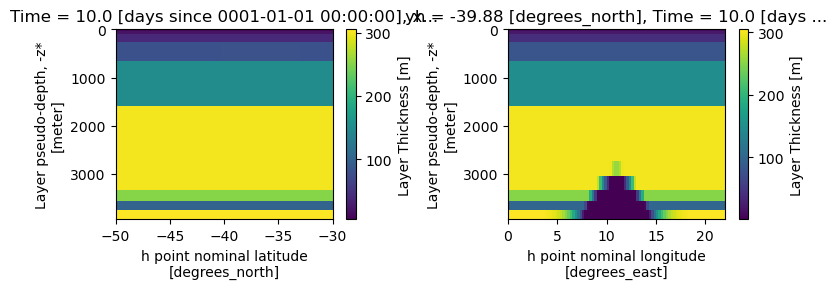

In [13]:
plt.figure(figsize=(8, 3))

plt.subplot(1,2,1)
ds_s_ann.h.isel(Time=-1, xh=0).plot()
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
ds_s_ann.h.isel(Time=-1, yh=40).plot()
plt.gca().invert_yaxis()

plt.tight_layout()

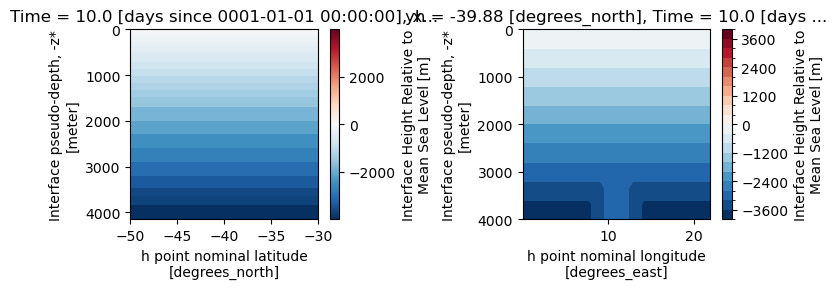

In [20]:
plt.figure(figsize=(8, 3))

plt.subplot(1,2,1)
ds_s_ann.e.isel(Time=-1, xh=0).plot()
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
ds_s_ann.e.isel(Time=-1, yh=40).plot.contourf(levels=21)
plt.gca().invert_yaxis()

plt.tight_layout()

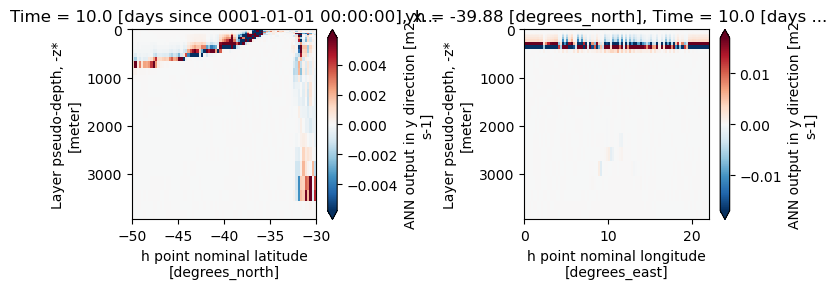

In [15]:
plt.figure(figsize=(8, 3))

plt.subplot(1,2,1)
ds_s_ann.Fy.isel(Time=-1, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
ds_s_ann.Fy.isel(Time=-1, yh=40).plot(robust=True)
plt.gca().invert_yaxis()

plt.tight_layout()

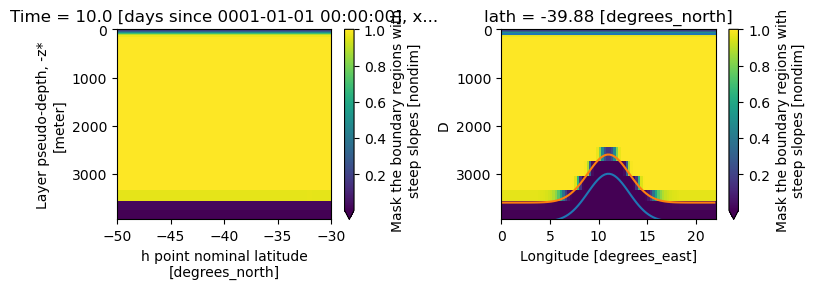

In [26]:
plt.figure(figsize=(8, 3))

plt.subplot(1,2,1)
ds_s_ann.boundary_mask.isel(Time=-1, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
ds_s_ann.boundary_mask.isel(Time=-1, yh=40).plot(robust=True)
ds_grid.D.isel(lath=40).plot()
(ds_grid.D - 400).isel(lath=40).plot()
plt.hlines(100, 0, 30)
plt.gca().invert_yaxis()

plt.tight_layout()

In [23]:
ds_grid.D.plot(

<xarray.DataArray 'D' (lath: 80, lonh: 88)>
[7040 values with dtype=float64]
Coordinates:
  * lath     (lath) float64 -49.88 -49.62 -49.38 -49.12 ... -30.62 -30.38 -30.12
  * lonh     (lonh) float64 0.125 0.375 0.625 0.875 ... 21.12 21.38 21.62 21.88
Attributes:
    long_name:  Basin Depth
    units:      meter